# EDA

In [2]:
# Load the canonical dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA_PATH = "../data/processed/ronaldo_1000_ml_canonical_final.csv"

df = pd.read_csv(DATA_PATH)
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

print("Shape:", df.shape)
print("Date range:", df["date"].min(), "→", df["date"].max())
print("Total goals:", df["target_goals"].sum())
print("Total appearances:", len(df))
print("Unique opponents:", df["opponent"].nunique())
print("Unique competitions:", df["competition"].nunique())

print("\nTarget distribution:")
print(df["target_goals"].value_counts().sort_index())

print("\nAppearances by team:")
print(df["team"].value_counts())

Shape: (1333, 92)
Date range: 2002-08-14 00:00:00 → 2026-08-28 00:00:00
Total goals: 978
Total appearances: 1333
Unique opponents: 283
Unique competitions: 31

Target distribution:
target_goals
0    676
1    415
2    176
3     55
4      9
5      2
Name: count, dtype: int64

Appearances by team:
team
Real Madrid          438
Manchester United    346
Portugal             233
Al-Nassr             151
Juventus             134
Sporting CP           31
Name: count, dtype: int64


## Analyze the target distribution

              matches  percentage
target_goals                     
0                 676       50.71
1                 415       31.13
2                 176       13.20
3                  55        4.13
4                   9        0.68
5                   2        0.15

Mean goals per appearance: 0.7337
Variance: 0.8187
Standard deviation: 0.9048

Scored in match: 49.29 %
Multi-goal match: 18.15 %


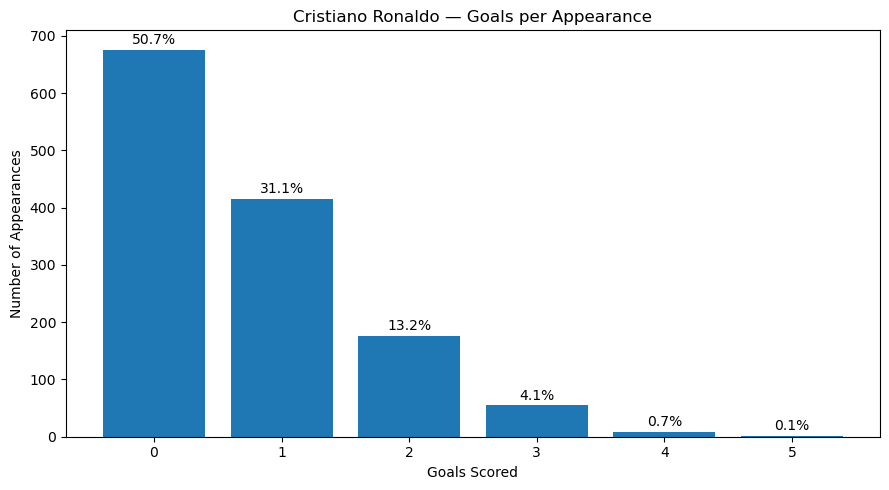

In [5]:
# Explore the goal-count target

goal_counts = df["target_goals"].value_counts().sort_index()
goal_pct = (
    df["target_goals"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
)

target_summary = pd.DataFrame({
    "matches": goal_counts,
    "percentage": goal_pct.round(2)
})

print(target_summary)

print("\nMean goals per appearance:", round(df["target_goals"].mean(), 4))
print("Variance:", round(df["target_goals"].var(), 4))
print("Standard deviation:", round(df["target_goals"].std(), 4))

print("\nScored in match:", round(df["target_scored"].mean() * 100, 2), "%")
print("Multi-goal match:", round(df["target_multi_goal"].mean() * 100, 2), "%")

# Visualize the count distribution
fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(
    target_summary.index,
    target_summary["matches"]
)

ax.set_title("Cristiano Ronaldo — Goals per Appearance")
ax.set_xlabel("Goals Scored")
ax.set_ylabel("Number of Appearances")
ax.set_xticks(target_summary.index)

for bar, pct in zip(bars, target_summary["percentage"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 10,
        f"{pct:.1f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

## Compare observed target distribution with Poisson expectation

Estimated Poisson lambda: 0.7337
Dispersion index: 1.1158

Observed vs Poisson expected:
   observed_matches  poisson_expected  difference
0               676            640.02       35.98
1               415            469.57      -54.57
2               176            172.26        3.74
3                55             42.13       12.87
4                 9              7.73        1.27
5                 2              1.13        0.87


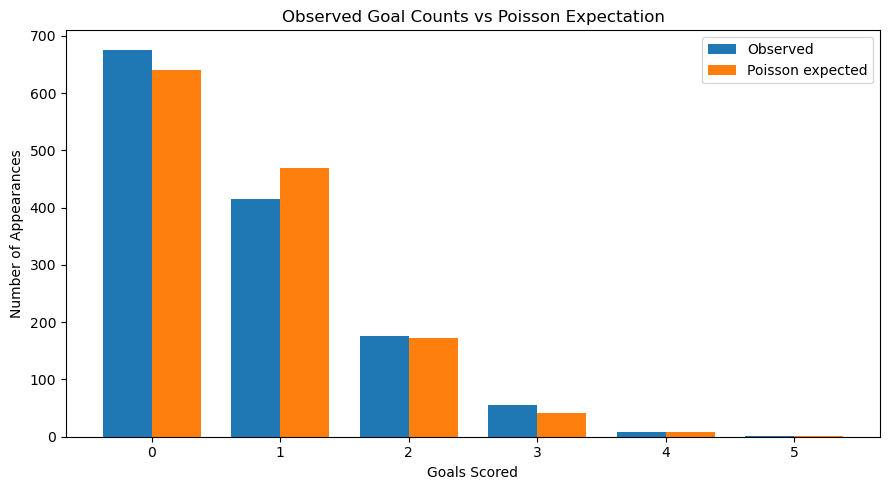

In [8]:
# Compare observed goal counts with a Poisson baseline

from scipy.stats import poisson

lambda_hat = df["target_goals"].mean()
n_matches = len(df)

goal_values = np.arange(0, df["target_goals"].max() + 1)

observed = (
    df["target_goals"]
    .value_counts()
    .reindex(goal_values, fill_value=0)
    .sort_index()
)

expected = pd.Series(
    poisson.pmf(goal_values, mu=lambda_hat) * n_matches,
    index=goal_values
)

poisson_comparison = pd.DataFrame({
    "observed_matches": observed,
    "poisson_expected": expected.round(2),
})

poisson_comparison["difference"] = (
    poisson_comparison["observed_matches"]
    - poisson_comparison["poisson_expected"]
).round(2)

print("Estimated Poisson lambda:", round(lambda_hat, 4))
print("Dispersion index:", round(df["target_goals"].var() / lambda_hat, 4))

print("\nObserved vs Poisson expected:")
print(poisson_comparison)

fig, ax = plt.subplots(figsize=(9, 5))

x = np.arange(len(goal_values))
width = 0.38

ax.bar(
    x - width / 2,
    poisson_comparison["observed_matches"],
    width,
    label="Observed"
)

ax.bar(
    x + width / 2,
    poisson_comparison["poisson_expected"],
    width,
    label="Poisson expected"
)

ax.set_title("Observed Goal Counts vs Poisson Expectation")
ax.set_xlabel("Goals Scored")
ax.set_ylabel("Number of Appearances")
ax.set_xticks(x)
ax.set_xticklabels(goal_values)
ax.legend()

plt.tight_layout()
plt.show()

## Goals per appearance by age

   age_years  appearances  goals  scoring_rate  goals_per_game
0    17.5199            1      0           0.0             0.0
1    17.6184            1      0           0.0             0.0
2    17.6485            1      0           0.0             0.0
3    17.6568            1      0           0.0             0.0
4    17.6677            1      2           1.0             2.0
5    17.7033            1      0           0.0             0.0
6    17.7197            1      1           1.0             1.0
7    17.7389            1      0           0.0             0.0
8    17.7553            1      0           0.0             0.0
9    17.7745            1      0           0.0             0.0

...
      age_years  appearances  goals  scoring_rate  goals_per_game
1323    41.3314            1      0           0.0             0.0
1324    41.3424            1      0           0.0             0.0
1325    41.3616            1      0           0.0             0.0
1326    41.3780            1      2   

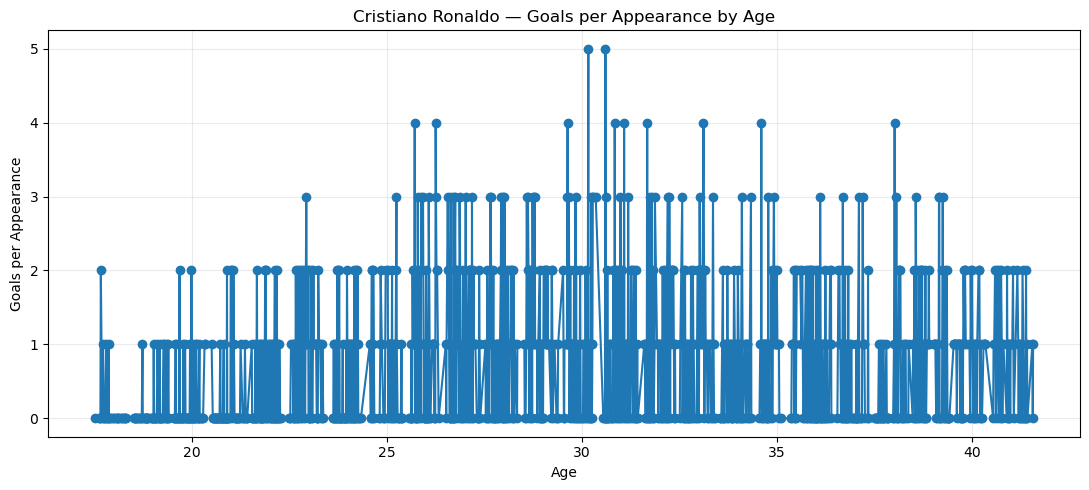

In [11]:
# Explore scoring rate across Ronaldo's age

age_summary = (
    df.groupby("age_years")
    .agg(
        appearances=("target_goals", "size"),
        goals=("target_goals", "sum"),
        scoring_rate=("target_scored", "mean"),
        goals_per_game=("target_goals", "mean"),
    )
    .reset_index()
)

print(age_summary.head(10))
print("\n...")
print(age_summary.tail(10))

fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(
    age_summary["age_years"],
    age_summary["goals_per_game"],
    marker="o"
)

ax.set_title("Cristiano Ronaldo — Goals per Appearance by Age")
ax.set_xlabel("Age")
ax.set_ylabel("Goals per Appearance")
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

## Age analysis correctly

    age_int  appearances  goals  scoring_rate  goals_per_game
0        17           20      5         0.200           0.250
1        18           35      1         0.029           0.029
2        19           67     17         0.224           0.254
3        20           60     13         0.183           0.217
4        21           60     26         0.333           0.433
5        22           61     40         0.475           0.656
6        23           59     30         0.390           0.508
7        24           45     28         0.444           0.622
8        25           64     53         0.516           0.828
9        26           60     59         0.567           0.983
10       27           70     67         0.614           0.957
11       28           61     64         0.672           1.049
12       29           56     60         0.714           1.071
13       30           56     58         0.518           1.036
14       31           58     54         0.569           0.931
15      

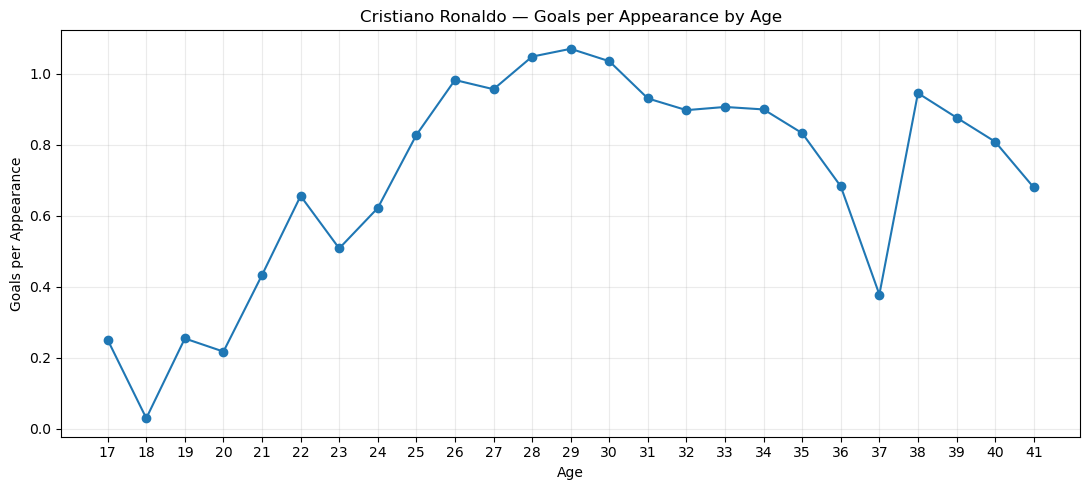

In [13]:
# Goals per appearance by whole age year

df["age_int"] = np.floor(df["age_years"]).astype(int)

age_summary = (
    df.groupby("age_int")
    .agg(
        appearances=("target_goals", "size"),
        goals=("target_goals", "sum"),
        scoring_rate=("target_scored", "mean"),
        goals_per_game=("target_goals", "mean"),
    )
    .reset_index()
)

age_summary["scoring_rate"] = age_summary["scoring_rate"].round(3)
age_summary["goals_per_game"] = age_summary["goals_per_game"].round(3)

print(age_summary)

fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(
    age_summary["age_int"],
    age_summary["goals_per_game"],
    marker="o"
)

ax.set_title("Cristiano Ronaldo — Goals per Appearance by Age")
ax.set_xlabel("Age")
ax.set_ylabel("Goals per Appearance")
ax.set_xticks(age_summary["age_int"])
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

## scoring by team

In [17]:
# Scoring performance by team

team_summary = (
    df.groupby("team")
    .agg(
        appearances=("target_goals", "size"),
        goals=("target_goals", "sum"),
        scoring_matches=("target_scored", "sum"),
        multi_goal_matches=("target_multi_goal", "sum"),
        goals_per_game=("target_goals", "mean"),
        scoring_rate=("target_scored", "mean"),
        multi_goal_rate=("target_multi_goal", "mean"),
    )
    .reset_index()
    .sort_values("goals_per_game", ascending=False)
)

team_summary["goals_per_game"] = team_summary["goals_per_game"].round(3)
team_summary["scoring_rate"] = team_summary["scoring_rate"].round(3)
team_summary["multi_goal_rate"] = team_summary["multi_goal_rate"].round(3)

print(team_summary.to_string(index=False))

             team  appearances  goals  scoring_matches  multi_goal_matches  goals_per_game  scoring_rate  multi_goal_rate
      Real Madrid          438    450              274                 122           1.027         0.626            0.279
         Al-Nassr          151    131               97                  27           0.868         0.642            0.179
         Juventus          134    101               75                  23           0.754         0.560            0.172
         Portugal          233    146               96                  38           0.627         0.412            0.163
Manchester United          346    145              111                  31           0.419         0.321            0.090
      Sporting CP           31      5                4                   1           0.161         0.129            0.032


## scoring by competition type

In [20]:
# Scoring performance by competition type

competition_type_summary = (
    df.groupby("competition_type")
    .agg(
        appearances=("target_goals", "size"),
        goals=("target_goals", "sum"),
        scoring_matches=("target_scored", "sum"),
        multi_goal_matches=("target_multi_goal", "sum"),
        goals_per_game=("target_goals", "mean"),
        scoring_rate=("target_scored", "mean"),
        multi_goal_rate=("target_multi_goal", "mean"),
    )
    .reset_index()
    .sort_values("goals_per_game", ascending=False)
)

competition_type_summary[
    ["goals_per_game", "scoring_rate", "multi_goal_rate"]
] = competition_type_summary[
    ["goals_per_game", "scoring_rate", "multi_goal_rate"]
].round(3)

print(competition_type_summary.to_string(index=False))

print("\nTotals:")
print("Appearances:", competition_type_summary["appearances"].sum())
print("Goals:", competition_type_summary["goals"].sum())

     competition_type  appearances  goals  scoring_matches  multi_goal_matches  goals_per_game  scoring_rate  multi_goal_rate
      domestic_league          761    602              394                 153           0.791         0.518            0.201
     continental_club          226    167              114                  43           0.739         0.504            0.190
        international          233    146               96                  38           0.627         0.412            0.163
domestic_or_other_cup          113     63               53                   8           0.558         0.469            0.071

Totals:
Appearances: 1333
Goals: 978


## Venue effect

In [23]:
# Scoring performance by venue

venue_summary = (
    df.groupby("venue")
    .agg(
        appearances=("target_goals", "size"),
        goals=("target_goals", "sum"),
        scoring_matches=("target_scored", "sum"),
        multi_goal_matches=("target_multi_goal", "sum"),
        goals_per_game=("target_goals", "mean"),
        scoring_rate=("target_scored", "mean"),
        multi_goal_rate=("target_multi_goal", "mean"),
    )
    .reset_index()
    .sort_values("goals_per_game", ascending=False)
)

venue_summary[
    ["goals_per_game", "scoring_rate", "multi_goal_rate"]
] = venue_summary[
    ["goals_per_game", "scoring_rate", "multi_goal_rate"]
].round(3)

print(venue_summary.to_string(index=False))

print("\nTotals:")
print("Appearances:", venue_summary["appearances"].sum())
print("Goals:", venue_summary["goals"].sum())

venue  appearances  goals  scoring_matches  multi_goal_matches  goals_per_game  scoring_rate  multi_goal_rate
    H          686    553              354                 148           0.806         0.516            0.216
    A          613    409              289                  92           0.667         0.471            0.150
    N           34     16               14                   2           0.471         0.412            0.059

Totals:
Appearances: 1333
Goals: 978


## recent scoring form

In [26]:
# Next-match scoring by goals scored in previous 5 appearances

form_last5_summary = (
    df.groupby("goals_last_5")
    .agg(
        appearances=("target_goals", "size"),
        next_match_goals=("target_goals", "sum"),
        next_match_scoring_rate=("target_scored", "mean"),
        next_match_goals_per_game=("target_goals", "mean"),
    )
    .reset_index()
)

form_last5_summary[
    ["next_match_scoring_rate", "next_match_goals_per_game"]
] = form_last5_summary[
    ["next_match_scoring_rate", "next_match_goals_per_game"]
].round(3)

print(form_last5_summary.to_string(index=False))

 goals_last_5  appearances  next_match_goals  next_match_scoring_rate  next_match_goals_per_game
            0           98                31                    0.265                      0.316
            1          164                82                    0.335                      0.500
            2          176               115                    0.455                      0.653
            3          223               171                    0.516                      0.767
            4          233               187                    0.558                      0.803
            5          157               162                    0.605                      1.032
            6          134               101                    0.545                      0.754
            7           70                54                    0.543                      0.771
            8           41                47                    0.610                      1.146
            9           20    

## compare multiple form windows

In [29]:
# Compare recent-goal windows

form_features = [
    "goals_last_3",
    "goals_last_5",
    "goals_last_10",
    "goals_last_20",
    "goals_ewma_pre",
]

form_correlations = (
    df[form_features + ["target_goals"]]
    .corr(numeric_only=True)["target_goals"]
    .drop("target_goals")
    .sort_values(ascending=False)
    .rename("correlation_with_next_match_goals")
    .round(3)
)

print(form_correlations)

goals_last_20     0.232
goals_last_10     0.207
goals_ewma_pre    0.160
goals_last_5      0.157
goals_last_3      0.110
Name: correlation_with_next_match_goals, dtype: float64


## scoring streak vs goalless streak

In [32]:
# Relationship between scoring streaks and next-match goals

streak_features = [
    "consecutive_scoring_games_pre",
    "goalless_streak_games_pre",
    "days_since_last_goal",
]

streak_summary = (
    df[streak_features + ["target_goals", "target_scored"]]
    .corr(numeric_only=True)[["target_goals", "target_scored"]]
    .loc[streak_features]
    .round(3)
)

print(streak_summary)

                               target_goals  target_scored
consecutive_scoring_games_pre         0.042          0.058
goalless_streak_games_pre            -0.121         -0.134
days_since_last_goal                 -0.120         -0.131


## Rest and match congestion

In [35]:
# Rest and schedule congestion vs next-match scoring

schedule_features = [
    "days_rest",
    "matches_last_7d",
    "matches_last_14d",
    "matches_last_30d",
]

schedule_relationships = (
    df[schedule_features + ["target_goals", "target_scored"]]
    .corr(numeric_only=True)[["target_goals", "target_scored"]]
    .loc[schedule_features]
    .round(3)
)

print(schedule_relationships)

print("\nSchedule feature ranges:")
print(
    df[schedule_features]
    .agg(["min", "median", "mean", "max"])
    .round(2)
)

                  target_goals  target_scored
days_rest               -0.047         -0.038
matches_last_7d          0.020          0.025
matches_last_14d         0.034          0.044
matches_last_30d         0.066          0.040

Schedule feature ranges:
        days_rest  matches_last_7d  matches_last_14d  matches_last_30d
min          2.00             0.00              0.00              0.00
median       4.00             1.00              2.00              5.00
mean         6.59             1.09              2.35              4.99
max         96.00             2.00              4.00              9.00


## Opponent-specific history

In [38]:
# Opponent-specific history vs next-match scoring

opponent_history_features = [
    "opponent_prior_meetings_pre",
    "ronaldo_goals_vs_opponent_pre",
    "ronaldo_goals_per_game_vs_opponent_pre",
    "ronaldo_scoring_rate_vs_opponent_pre",
    "ronaldo_goals_last_3_vs_opponent_pre",
]

opponent_relationships = (
    df[opponent_history_features + ["target_goals", "target_scored"]]
    .corr(numeric_only=True)[["target_goals", "target_scored"]]
    .loc[opponent_history_features]
    .round(3)
)

print(opponent_relationships)

print("\nOpponent-history coverage:")
print(
    "Matches with at least one prior meeting:",
    (df["opponent_prior_meetings_pre"] > 0).sum()
)

print(
    "First-time opponent matches:",
    (df["opponent_prior_meetings_pre"] == 0).sum()
)

print(
    "Maximum prior meetings against one opponent:",
    df["opponent_prior_meetings_pre"].max()
)

                                        target_goals  target_scored
opponent_prior_meetings_pre                    0.029          0.037
ronaldo_goals_vs_opponent_pre                  0.096          0.090
ronaldo_goals_per_game_vs_opponent_pre         0.176          0.170
ronaldo_scoring_rate_vs_opponent_pre           0.154          0.157
ronaldo_goals_last_3_vs_opponent_pre           0.150          0.131

Opponent-history coverage:
Matches with at least one prior meeting: 1050
First-time opponent matches: 283
Maximum prior meetings against one opponent: 36


## Team-vs-opponent H2H strength

In [41]:
# Team-vs-opponent H2H vs next-match scoring

h2h_features = [
    "team_h2h_wins_pre",
    "team_h2h_draws_pre",
    "team_h2h_losses_pre",
    "opponent_h2h_points_per_game_pre",
    "opponent_h2h_unbeaten_rate_pre",
    "opponent_goals_for_per_h2h_scored_match_pre",
    "opponent_goals_against_per_h2h_scored_match_pre",
    "opponent_clean_sheet_rate_h2h_scored_match_pre",
    "opponent_score_data_h2h_matches_pre",
]

h2h_relationships = (
    df[h2h_features + ["target_goals", "target_scored"]]
    .corr(numeric_only=True)[["target_goals", "target_scored"]]
    .loc[h2h_features]
    .round(3)
)

print(h2h_relationships)

                                                 target_goals  target_scored
team_h2h_wins_pre                                       0.104          0.087
team_h2h_draws_pre                                     -0.027         -0.005
team_h2h_losses_pre                                    -0.034         -0.013
opponent_h2h_points_per_game_pre                       -0.063         -0.078
opponent_h2h_unbeaten_rate_pre                         -0.066         -0.075
opponent_goals_for_per_h2h_scored_match_pre            -0.080         -0.075
opponent_goals_against_per_h2h_scored_match_pre         0.140          0.153
opponent_clean_sheet_rate_h2h_scored_match_pre         -0.082         -0.090
opponent_score_data_h2h_matches_pre                     0.046          0.049


## Matchup Elo

In [44]:
# Matchup Elo vs next-match scoring

elo_features = [
    "team_matchup_elo_pre",
    "opponent_matchup_elo_pre",
    "matchup_elo_diff_pre",
    "opponent_matchup_elo_games_pre",
]

elo_relationships = (
    df[elo_features + ["target_goals", "target_scored"]]
    .corr(numeric_only=True)[["target_goals", "target_scored"]]
    .loc[elo_features]
    .round(3)
)

print(elo_relationships)

print("\nElo feature ranges:")
print(
    df[elo_features]
    .agg(["min", "median", "mean", "max"])
    .round(2)
)

                                target_goals  target_scored
team_matchup_elo_pre                   0.223          0.225
opponent_matchup_elo_pre              -0.062         -0.034
matchup_elo_diff_pre                   0.235          0.225
opponent_matchup_elo_games_pre         0.000          0.026

Elo feature ranges:
        team_matchup_elo_pre  opponent_matchup_elo_pre  matchup_elo_diff_pre  \
min                  1480.29                   1433.20               -105.63   
median               1677.72                   1500.00                173.03   
mean                 1671.01                   1502.18                168.83   
max                  1797.88                   1726.73                304.97   

        opponent_matchup_elo_games_pre  
min                               0.00  
median                            3.00  
mean                              5.76  
max                             296.00  


## Team recent form

In [47]:
# Step 2O — Team recent form vs Ronaldo's next-match scoring

team_form_features = [
    "team_points_last_5_ronaldo_apps_pre",
    "team_points_last_10_ronaldo_apps_pre",
    "team_win_rate_last_5_ronaldo_apps_pre",
    "team_unbeaten_rate_last_5_ronaldo_apps_pre",
    "team_goals_for_last_5_scored_matches_pre",
    "team_goals_against_last_5_scored_matches_pre",
    "team_score_coverage_last_5_pre",
]

team_form_relationships = (
    df[team_form_features + ["target_goals", "target_scored"]]
    .corr(numeric_only=True)[["target_goals", "target_scored"]]
    .loc[team_form_features]
    .round(3)
)

print(team_form_relationships)

                                              target_goals  target_scored
team_points_last_5_ronaldo_apps_pre                  0.044          0.049
team_points_last_10_ronaldo_apps_pre                 0.077          0.097
team_win_rate_last_5_ronaldo_apps_pre                0.045          0.048
team_unbeaten_rate_last_5_ronaldo_apps_pre          -0.002         -0.011
team_goals_for_last_5_scored_matches_pre             0.133          0.119
team_goals_against_last_5_scored_matches_pre         0.093          0.093
team_score_coverage_last_5_pre                       0.049          0.065


## Age and career-time trend

In [50]:
# Age and career progression vs next-match scoring

career_time_features = [
    "age_years",
    "career_appearances_pre",
    "career_goals_pre",
    "season_appearances_pre",
]

career_time_relationships = (
    df[career_time_features + ["target_goals", "target_scored"]]
    .corr(numeric_only=True)[["target_goals", "target_scored"]]
    .loc[career_time_features]
    .round(3)
)

print(career_time_relationships)

print("\nCareer age range:")
print("First appearance age:", round(df["age_years"].min(), 2))
print("Latest appearance age:", round(df["age_years"].max(), 2))

                        target_goals  target_scored
age_years                      0.171          0.208
career_appearances_pre         0.176          0.212
career_goals_pre               0.155          0.191
season_appearances_pre         0.017          0.020

Career age range:
First appearance age: 17.52
Latest appearance age: 41.56


## missingness accross career time

In [53]:
# Missingness across career periods

missingness_features = [
    "goals_ewma_pre",
    "days_since_last_goal",
    "ronaldo_goals_per_game_vs_opponent_pre",
    "opponent_h2h_points_per_game_pre",
    "team_points_last_5_ronaldo_apps_pre",
    "team_matchup_elo_pre",
    "opponent_matchup_elo_pre",
]

df["career_period"] = pd.cut(
    df["date"].dt.year,
    bins=[2001, 2006, 2011, 2016, 2021, 2026],
    labels=[
        "2002-2006",
        "2007-2011",
        "2012-2016",
        "2017-2021",
        "2022-2026",
    ],
)

missingness_by_period = (
    df.groupby("career_period", observed=True)[missingness_features]
    .apply(lambda x: x.isna().mean() * 100)
    .round(1)
)

print("Missing values by career period (%):")
print(missingness_by_period.to_string())

Missing values by career period (%):
               goals_ewma_pre  days_since_last_goal  ronaldo_goals_per_game_vs_opponent_pre  opponent_h2h_points_per_game_pre  team_points_last_5_ronaldo_apps_pre  team_matchup_elo_pre  opponent_matchup_elo_pre
career_period                                                                                                                                                                                                     
2002-2006                 0.0                   2.1                                     0.0                               0.0                                  0.0                   0.0                       0.0
2007-2011                 0.0                   0.0                                     0.0                               0.0                                  0.0                   0.0                       0.0
2012-2016                 0.0                   0.0                                     0.0                            

## Full numeric feature correlation ranking

In [56]:
# Global numeric correlation ranking

excluded_columns = {
    # Targets
    "target_goals",
    "target_scored",
    "target_multi_goal",

    # Post-match / leakage columns
    "team_goals",
    "opponent_goals",
    "result",
    "ronaldo_goals",
    "ronaldo_assists",
    "source_status",

    # Identifiers / EDA helpers
    "match_id",
    "age_int",
    "career_period",
}

numeric_features = [
    col for col in df.select_dtypes(include="number").columns
    if col not in excluded_columns
]

goal_correlations = (
    df[numeric_features + ["target_goals"]]
    .corr(numeric_only=True)["target_goals"]
    .drop("target_goals")
    .sort_values(key=lambda x: x.abs(), ascending=False)
)

print("Number of numeric pre-match features:", len(numeric_features))

print("\nTop 25 correlations with target_goals:")
print(goal_correlations.head(25).round(3).to_string())

print("\nBottom 10 / weakest correlations:")
print(
    goal_correlations
    .sort_values(key=lambda x: x.abs())
    .head(10)
    .round(3)
    .to_string()
)

Number of numeric pre-match features: 74

Top 25 correlations with target_goals:
team_ronaldo_goals_per_game_pre           0.283
competition_goals_per_game_pre            0.244
matchup_elo_diff_pre                      0.235
goals_last_20                             0.232
goals_per_game_last_20                    0.231
venue_goals_per_game_pre                  0.226
season_goals_per_game_pre                 0.224
team_matchup_elo_pre                      0.223
career_goals_per_game_pre                 0.222
scoring_rate_last_10                      0.208
goals_last_10                             0.207
goals_per_game_last_10                    0.207
team_goals_by_ronaldo_pre                 0.191
venue_appearances_pre                     0.183
career_assists_pre                        0.179
competition_goals_pre                     0.179
ronaldo_goals_per_game_vs_opponent_pre    0.176
career_appearances_pre                    0.176
age_years                                 0.171
age_day

## Check redundancy among the strongest predictors

In [60]:
# Correlation between strongest numeric predictors

top_features = goal_correlations.head(15).index.tolist()

feature_corr = df[top_features].corr(numeric_only=True)

high_corr_pairs = []

for i in range(len(top_features)):
    for j in range(i + 1, len(top_features)):
        feature_a = top_features[i]
        feature_b = top_features[j]

        corr_value = feature_corr.loc[feature_a, feature_b]

        if abs(corr_value) >= 0.80:
            high_corr_pairs.append(
                (feature_a, feature_b, round(corr_value, 3))
            )

high_corr_pairs = sorted(
    high_corr_pairs,
    key=lambda x: abs(x[2]),
    reverse=True
)

print("Highly correlated predictor pairs (|r| >= 0.80):")

if high_corr_pairs:
    for feature_a, feature_b, corr_value in high_corr_pairs:
        print(f"{feature_a}  <->  {feature_b}: {corr_value}")
else:
    print("None found.")

Highly correlated predictor pairs (|r| >= 0.80):
goals_last_10  <->  goals_per_game_last_10: 1.0
goals_last_20  <->  goals_per_game_last_20: 0.999
venue_appearances_pre  <->  career_assists_pre: 0.967
career_goals_per_game_pre  <->  career_assists_pre: 0.959
venue_goals_per_game_pre  <->  career_goals_per_game_pre: 0.926
career_goals_per_game_pre  <->  venue_appearances_pre: 0.917
matchup_elo_diff_pre  <->  team_matchup_elo_pre: 0.904
venue_goals_per_game_pre  <->  career_assists_pre: 0.888
scoring_rate_last_10  <->  goals_last_10: 0.886
scoring_rate_last_10  <->  goals_per_game_last_10: 0.886
venue_goals_per_game_pre  <->  venue_appearances_pre: 0.885
goals_per_game_last_20  <->  goals_last_10: 0.853
goals_per_game_last_20  <->  goals_per_game_last_10: 0.853
goals_last_20  <->  goals_last_10: 0.852
goals_last_20  <->  goals_per_game_last_10: 0.851
goals_per_game_last_20  <->  season_goals_per_game_pre: 0.818
goals_last_20  <->  season_goals_per_game_pre: 0.817
goals_last_20  <->  scor

## Check categorical features

In [63]:
# Inspect categorical pre-match features

excluded_categorical = {
    "match_id",
    "date",
    "result",
    "source_status",
    "career_period",
}

categorical_features = [
    col
    for col in df.select_dtypes(include=["object", "category"]).columns
    if col not in excluded_categorical
]

print("Categorical pre-match features:", len(categorical_features))

for col in categorical_features:
    print(
        f"{col:<30} "
        f"unique={df[col].nunique(dropna=True):>4}   "
        f"missing={df[col].isna().sum():>4}"
    )

Categorical pre-match features: 7
season                         unique=  25   missing=   0
team                           unique=   6   missing=   0
opponent                       unique= 283   missing=   0
competition                    unique=  31   missing=   0
competition_type               unique=   4   missing=   0
venue                          unique=   3   missing=   0
day_of_week                    unique=   7   missing=   0


## Rare-category analysis

In [66]:
# Rare-category analysis

for col in ["opponent", "competition"]:
    counts = df[col].value_counts()

    print(f"\n--- {col.upper()} ---")
    print("Unique categories:", counts.size)
    print("Categories appearing once:", (counts == 1).sum())
    print("Categories with fewer than 5 appearances:", (counts < 5).sum())
    print("Categories with fewer than 10 appearances:", (counts < 10).sum())

    print("\n10 most frequent:")
    print(counts.head(10).to_string())

    print("\n10 least frequent:")
    print(counts.tail(10).to_string())


--- OPPONENT ---
Unique categories: 283
Categories appearing once: 76
Categories with fewer than 5 appearances: 184
Categories with fewer than 10 appearances: 245

10 most frequent:
opponent
Atletico Madrid      37
Barcelona            34
Villarreal           21
Valencia             20
Tottenham Hotspur    20
Malaga               19
Arsenal              18
Athletic Club        18
Sevilla              18
Chelsea              17

10 least frequent:
opponent
Algeria          1
Hull City        1
Liga de Quito    1
South Africa     1
Empoli           1
China            1
Mozambique       1
Ivory Coast      1
North Korea      1
Colombia         1

--- COMPETITION ---
Unique categories: 31
Categories appearing once: 1
Categories with fewer than 5 appearances: 7
Categories with fewer than 10 appearances: 15

10 most frequent:
competition
La Liga                             292
Premier League                      236
UEFA Champions League               183
Pro League                          

## Temporal stability of scoring rate

In [70]:
# Season-by-season scoring trend

season_trend = (
    df.groupby("season")
    .agg(
        appearances=("target_goals", "size"),
        goals=("target_goals", "sum"),
        scoring_matches=("target_scored", "sum"),
        goals_per_game=("target_goals", "mean"),
        scoring_rate=("target_scored", "mean"),
    )
    .reset_index()
)

season_trend[
    ["goals_per_game", "scoring_rate"]
] = season_trend[
    ["goals_per_game", "scoring_rate"]
].round(3)

print(season_trend.to_string(index=False))

 season  appearances  goals  scoring_matches  goals_per_game  scoring_rate
2002/03           31      5                4           0.161         0.129
2003/04           53      8                8           0.151         0.151
2004/05           60     16               14           0.267         0.233
2005/06           62     15               11           0.242         0.177
2006/07           61     28               22           0.459         0.361
2007/08           61     46               34           0.754         0.557
2008/09           60     27               20           0.450         0.333
2009/10           46     34               24           0.739         0.522
2010/11           59     56               31           0.949         0.525
2011/12           69     69               43           1.000         0.623
2012/13           64     59               39           0.922         0.609
2013/14           57     62               40           1.088         0.702
2014/15           60     

## Recent-era trend

In [73]:
# Recent scoring trend most relevant to the 1000-goal forecast

recent_df = df[df["date"] >= "2022-01-01"].copy()

recent_year_summary = (
    recent_df.groupby(recent_df["date"].dt.year)
    .agg(
        appearances=("target_goals", "size"),
        goals=("target_goals", "sum"),
        scoring_matches=("target_scored", "sum"),
        multi_goal_matches=("target_multi_goal", "sum"),
        goals_per_game=("target_goals", "mean"),
        scoring_rate=("target_scored", "mean"),
        multi_goal_rate=("target_multi_goal", "mean"),
    )
    .reset_index()
    .rename(columns={"date": "year"})
)

recent_year_summary[
    ["goals_per_game", "scoring_rate", "multi_goal_rate"]
] = recent_year_summary[
    ["goals_per_game", "scoring_rate", "multi_goal_rate"]
].round(3)

print(recent_year_summary.to_string(index=False))

print("\nRecent-era totals:")
print("Appearances:", len(recent_df))
print("Goals:", recent_df["target_goals"].sum())
print(
    "Goals per game:",
    round(recent_df["target_goals"].mean(), 3)
)

 year  appearances  goals  scoring_matches  multi_goal_matches  goals_per_game  scoring_rate  multi_goal_rate
 2022           46     16               11                   3           0.348         0.239            0.065
 2023           59     54               36                  14           0.915         0.610            0.237
 2024           51     43               31                   9           0.843         0.608            0.176
 2025           46     41               32                   9           0.891         0.696            0.196
 2026           32     21               17                   4           0.656         0.531            0.125

Recent-era totals:
Appearances: 234
Goals: 175
Goals per game: 0.748


## Last 10/20/30/50 appearances at the cutoff

In [76]:
# Step 2X — Ronaldo's scoring state at the dataset cutoff

windows = [10, 20, 30, 50, 100]

rows = []

for window in windows:
    recent = df.tail(window)

    rows.append({
        "last_n_apps": window,
        "goals": recent["target_goals"].sum(),
        "scoring_matches": recent["target_scored"].sum(),
        "multi_goal_matches": recent["target_multi_goal"].sum(),
        "goals_per_game": recent["target_goals"].mean(),
        "scoring_rate": recent["target_scored"].mean(),
        "multi_goal_rate": recent["target_multi_goal"].mean(),
    })

cutoff_form = pd.DataFrame(rows)

cutoff_form[
    ["goals_per_game", "scoring_rate", "multi_goal_rate"]
] = cutoff_form[
    ["goals_per_game", "scoring_rate", "multi_goal_rate"]
].round(3)

print(cutoff_form.to_string(index=False))

print("\nLatest appearance:")
print("Date:", df.iloc[-1]["date"])
print("Team:", df.iloc[-1]["team"])
print("Opponent:", df.iloc[-1]["opponent"])
print("Career goals after match:", df["target_goals"].sum())
print("Goals remaining to 1000:", 1000 - df["target_goals"].sum())

 last_n_apps  goals  scoring_matches  multi_goal_matches  goals_per_game  scoring_rate  multi_goal_rate
          10      5                4                   1           0.500         0.400            0.100
          20     11                9                   2           0.550         0.450            0.100
          30     20               16                   4           0.667         0.533            0.133
          50     39               30                   9           0.780         0.600            0.180
         100     81               65                  16           0.810         0.650            0.160

Latest appearance:
Date: 2026-08-28 00:00:00
Team: Al-Nassr
Opponent: Al Taawon
Career goals after match: 978
Goals remaining to 1000: 22


## Inspect the final pre-match state

In [79]:
# Inspect state at the forecasting cutoff

state_features = [
    "career_appearances_pre",
    "career_goals_pre",
    "goals_to_1000_pre",
    "career_goals_per_game_pre",
    "goals_last_3",
    "goals_last_5",
    "goals_last_10",
    "goals_last_20",
    "goals_ewma_pre",
    "consecutive_scoring_games_pre",
    "goalless_streak_games_pre",
    "days_since_last_goal",
    "season_appearances_pre",
    "season_goals_per_game_pre",
    "team_appearances_with_ronaldo_pre",
    "team_ronaldo_goals_per_game_pre",
]

latest = df.iloc[-1]

print("Final recorded appearance:")
print(f"{latest['date'].date()} | {latest['team']} vs {latest['opponent']}")
print(f"Goals scored in match: {latest['target_goals']}")

print("\nPre-match state entering that appearance:")
for feature in state_features:
    print(f"{feature:<40} {latest[feature]}")

print("\nState immediately after the appearance:")
print("Career appearances:", int(latest["career_appearances_pre"] + 1))
print("Career goals:", int(latest["career_goals_pre"] + latest["target_goals"]))
print(
    "Goals remaining to 1000:",
    int(1000 - (latest["career_goals_pre"] + latest["target_goals"]))
)

Final recorded appearance:
2026-08-28 | Al-Nassr vs Al Taawon
Goals scored in match: 1

Pre-match state entering that appearance:
career_appearances_pre                   1332
career_goals_pre                         977
goals_to_1000_pre                        23
career_goals_per_game_pre                0.7334834834834835
goals_last_3                             1
goals_last_5                             2
goals_last_10                            6
goals_last_20                            12
goals_ewma_pre                           0.4469198854176679
consecutive_scoring_games_pre            0
goalless_streak_games_pre                1
days_since_last_goal                     7.0
season_appearances_pre                   2
season_goals_per_game_pre                0.5
team_appearances_with_ronaldo_pre        150
team_ronaldo_goals_per_game_pre          0.8666666666666667

State immediately after the appearance:
Career appearances: 1333
Career goals: 978
Goals remaining to 1000: 22


## Final EDA data-quality check

In [82]:
# Final EDA integrity check

import numpy as np

# Temporary EDA-only columns
eda_helper_columns = ["age_int", "career_period"]

print("Dataset shape:", df.shape)

print("\nEDA helper columns currently present:")
for col in eda_helper_columns:
    print(f"{col}: {col in df.columns}")

print("\nCore integrity:")
print("Rows:", len(df))
print("Unique match IDs:", df["match_id"].nunique())
print("Total goals:", df["target_goals"].sum())
print("First date:", df["date"].min())
print("Last date:", df["date"].max())

numeric_df = df.select_dtypes(include="number")

print("\nNumeric data quality:")
print("Total missing numeric values:", numeric_df.isna().sum().sum())
print(
    "Total infinite numeric values:",
    np.isinf(numeric_df.to_numpy()).sum()
)

missing_numeric = numeric_df.isna().sum()
missing_numeric = missing_numeric[missing_numeric > 0].sort_values(ascending=False)

print("\nNumeric columns containing missing values:")
if len(missing_numeric):
    print(missing_numeric.to_string())
else:
    print("None")

Dataset shape: (1333, 94)

EDA helper columns currently present:
age_int: True
career_period: True

Core integrity:
Rows: 1333
Unique match IDs: 1333
Total goals: 978
First date: 2002-08-14 00:00:00
Last date: 2026-08-28 00:00:00

Numeric data quality:
Total missing numeric values: 957
Total infinite numeric values: 0

Numeric columns containing missing values:
opponent_goals_for_per_h2h_scored_match_pre        313
opponent_goals_against_per_h2h_scored_match_pre    313
opponent_clean_sheet_rate_h2h_scored_match_pre     313
team_goals_for_last_5_scored_matches_pre             6
team_goals_against_last_5_scored_matches_pre         6
days_since_last_goal                                 5
days_rest                                            1
